In [1]:
import maboss
import pandas as pd
import numpy as np

In [8]:
model_or = maboss.loadBNet('/home/spankaew/Git/Git_Curie/AstroLogics/models/herault_hematopoiesis/bn0.bnet')
model_and = maboss.loadBNet('/home/spankaew/Git/Git_Curie/AstroLogics/models/herault_hematopoiesis/bn1.bnet')


In [10]:
# Adjust the simulation parameter
model_or.param['max_time'] = 20
model_or.param['time_tick'] = 1
model_or.param['thread_count'] = 15

# Adjust the parameter
model_and.param['max_time'] = 20
model_and.param['time_tick'] = 1
model_and.param['thread_count'] = 15

node_names = model_or.network.names
for node in node_names:
    model_or.network.set_istate(node, [0.5, 0.5])
    model_and.network.set_istate(node, [0.5, 0.5])

model_or.network.set_output(model_or.network.names)
model_and.network.set_output(model_and.network.names)

In [14]:
sim_or = model_or.run()
sim_and = model_and.run()

node_or = sim_or.get_nodes_probtraj()
node_and = sim_and.get_nodes_probtraj()

In [15]:
node_or

,Myc,Bclaf1,CDK46CycD,Junb,CIPKIP,Gata2,Ikzf1,Spi1,Cebpa,Egr1,Gata1,Klf1,Fli1,Zfpm1,Tal1
0.0,0.398658,0.475243,0.544122,0.559787,0.519765,0.436438,0.483136,0.419667,0.434234,0.407476,0.567208,0.389557,0.528813,0.520514,0.450405
1.0,0.252420,0.371666,0.491918,0.538820,0.546592,0.315947,0.406581,0.310959,0.311947,0.295262,0.669011,0.241681,0.624843,0.592193,0.488893
2.0,0.158755,0.258733,0.376767,0.436140,0.505642,0.220408,0.310994,0.242356,0.225977,0.218708,0.735158,0.160674,0.680760,0.667709,0.582051
3.0,0.099738,0.173470,0.269739,0.332781,0.420559,0.148704,0.226023,0.189224,0.169179,0.155750,0.774445,0.122933,0.707279,0.725750,0.663915
4.0,0.065280,0.116871,0.188057,0.243302,0.329289,0.098678,0.155923,0.154337,0.132197,0.106370,0.792630,0.104572,0.715930,0.761451,0.723204
5.0,0.042350,0.077197,0.128767,0.170198,0.248955,0.069571,0.109472,0.134173,0.111336,0.067058,0.802018,0.096325,0.719827,0.782653,0.759416
6.0,0.027317,0.048163,0.083498,0.115159,0.180193,0.052638,0.077069,0.122555,0.098947,0.040366,0.806820,0.092182,0.721601,0.797460,0.782386
7.0,0.017261,0.030756,0.054922,0.075954,0.124814,0.040539,0.056344,0.115894,0.090403,0.023547,0.809646,0.090355,0.722472,0.804531,0.794662
8.0,0.010949,0.020104,0.036106,0.045951,0.082176,0.034854,0.043237,0.112726,0.085324,0.012523,0.810712,0.089635,0.722750,0.808149,0.802001
9.0,0.006609,0.013527,0.024259,0.026504,0.051534,0.032686,0.036578,0.110519,0.082781,0.006529,0.811373,0.089007,0.723016,0.809550,0.805669


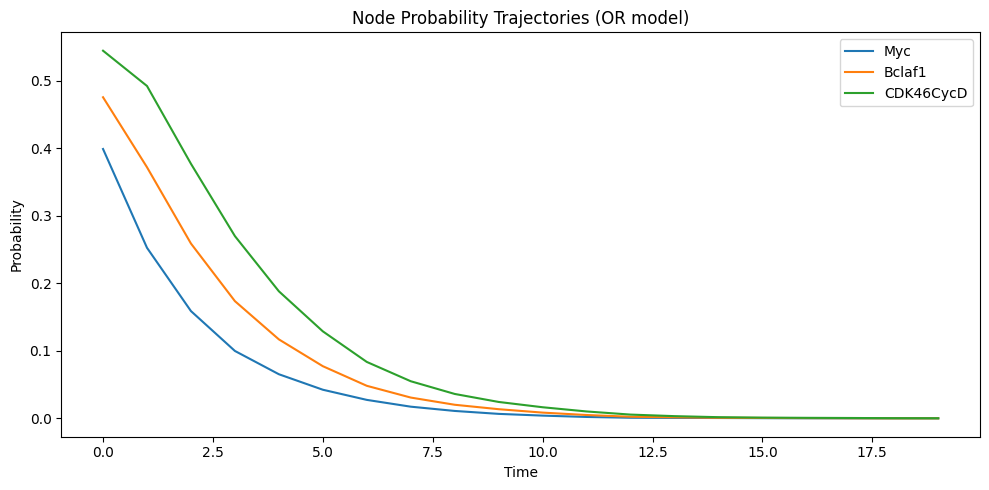

In [16]:
import matplotlib.pyplot as plt

nodes_to_plot = ['Myc', 'Bclaf1', 'CDK46CycD']

fig, ax = plt.subplots(figsize=(10, 5))

for node in nodes_to_plot:
    ax.plot(node_or.index, node_or[node], label=node)

ax.set_xlabel('Time')
ax.set_ylabel('Probability')
ax.set_title('Node Probability Trajectories (OR model)')
ax.legend()
plt.tight_layout()
plt.show()


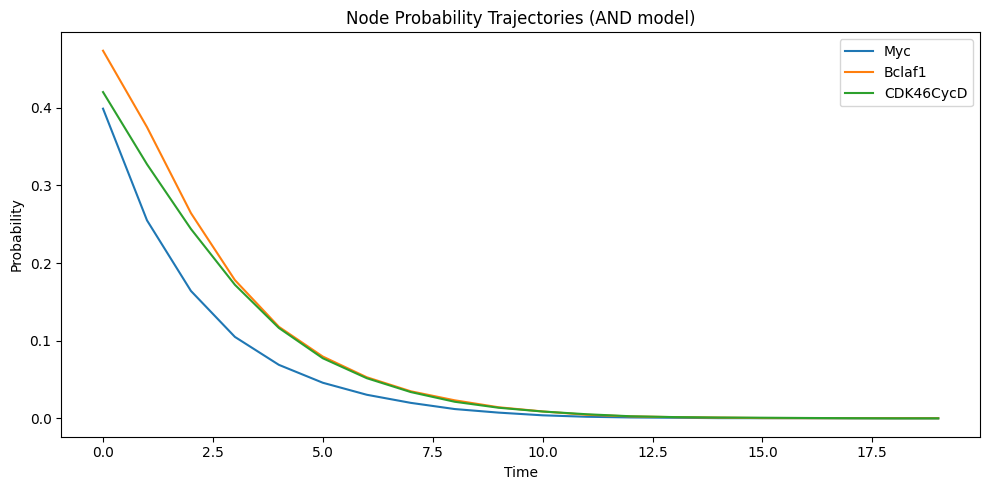

In [17]:
import matplotlib.pyplot as plt

nodes_to_plot = ['Myc', 'Bclaf1', 'CDK46CycD']

fig, ax = plt.subplots(figsize=(10, 5))

for node in nodes_to_plot:
    ax.plot(node_and.index, node_and[node], label=node)

ax.set_xlabel('Time')
ax.set_ylabel('Probability')
ax.set_title('Node Probability Trajectories (AND model)')
ax.legend()
plt.tight_layout()
plt.show()
